## Sección 0: Configuración del problema de RUL proxy

**Por qué "proxy" y no RUL real.** El dataset UCI Hydraulic System no incluye una variable de Vida Útil Remanente (RUL) directa — los ciclos son experimentos de laboratorio controlados (diseño factorial de 144 combinaciones, ya documentado en el EDA), no una serie temporal de degradación continua de una única máquina hasta el fallo. Por tanto, cualquier RUL que se construya aquí es un **proxy sintético**: una puntuación ordinal de salud derivada del estado predicho de los cuatro componentes, que representa cuánto le "queda por degradarse" a la máquina respecto al estado óptimo simultáneo de todos los componentes.

**Este enfoque es el inverso del RUL clásico.** En el RUL clásico se dispone de una serie temporal hasta el fallo y se predice el tiempo restante. Aquí la construcción va en la dirección opuesta: se parte de predicciones de estado de degradación ya disponibles (Fase 4) y se define una función de salud compuesta que mapea el vector de cuatro estados a un índice escalar. El resultado no tiene unidades de tiempo — es una puntuación de salud relativa que va de 0 (peor estado observado) a 1 (estado óptimo en todos los componentes). El valor de este proxy no está en predecir el momento de fallo futuro, sino en **ordenar los ciclos por severidad de degradación compuesta** y generar una señal continua útil para alertas de mantenimiento, que no existía hasta ahora en el pipeline.

**Las entradas de esta fase son exclusivamente artefactos ya producidos, no datos nuevos.** `predictions_test.parquet` de la Fase 4 (predicciones de estado por componente, 290 filas), `anomaly_scores_test.parquet` de la Fase 3 (scores de Mahalanobis y de Isolation Forest, 290 filas), e `y_test.parquet` (etiquetas reales, 290 filas). Las **predicciones** de la Fase 4 se usan como input principal para construir el proxy — no las etiquetas reales — porque en un escenario de despliegue real las etiquetas no están disponibles en el momento de calcular el proxy: solo se dispone de lo que el modelo predice a partir de los sensores. Las etiquetas reales de `y_test` se reservan exclusivamente para **validar** el proxy ya construido, nunca para construirlo — la misma disciplina de separación que ha regido las Fases 2, 3 y 4.

### Imports y configuración

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

COMPONENTS = ["cooler_condition", "valve_condition", "pump_leakage", "accumulator_pressure"]


In [2]:
# ── Carga de los 3 artefactos ya producidos por las Fases 3 y 4 ──
predictions_test = pd.read_parquet(PROCESSED_DIR / "predictions_test.parquet")
anomaly_scores_test = pd.read_parquet(PROCESSED_DIR / "anomaly_scores_test.parquet")
y_test = pd.read_parquet(PROCESSED_DIR / "y_test.parquet")

# ── Construcción de df: concatenar columnas evitando duplicar y_test_anomaly ──
# y_test_anomaly está en predictions_test y en anomaly_scores_test — se conserva la de predictions_test
# (Fase 4, calculada sobre el mismo criterio) y se descarta la de anomaly_scores_test antes de concatenar.
anomaly_scores_test_dedup = anomaly_scores_test.drop(columns=["y_test_anomaly"])

df = pd.concat([predictions_test, anomaly_scores_test_dedup, y_test], axis=1)

print(f"df: {df.shape}")
print(f"\nColumnas: {list(df.columns)}")
print(f"\nNaN totales: {int(df.isna().sum().sum())}")

assert df.shape[0] == 290, f"Se esperaban 290 filas, se obtuvieron {df.shape[0]}"
assert df.isna().sum().sum() == 0, "Se encontraron NaN en df"
print("\nVerificación de filas (290) y NaN (0): OK")


df: (290, 11)

Columnas: ['pred_cooler_condition', 'pred_valve_condition', 'pred_pump_leakage', 'pred_accumulator_pressure', 'y_test_anomaly', 'maha2_test', 'anomaly_score_if_test', 'cooler_condition', 'valve_condition', 'pump_leakage', 'accumulator_pressure']

NaN totales: 0

Verificación de filas (290) y NaN (0): OK


In [3]:
# ── Mapeos de degradación ordinal por componente (0 = óptimo, mayor = más degradado) ──
degradation_maps = {
    "cooler_condition": {100: 0, 20: 1, 3: 2},
    "valve_condition": {100: 0, 90: 1, 80: 2, 73: 3},
    "pump_leakage": {0: 0, 1: 1, 2: 2},
    "accumulator_pressure": {130: 0, 115: 1, 100: 2, 90: 3},
}

# ── Aplicar los mapeos sobre las predicciones (Fase 4) y sobre las etiquetas reales (validación) ──
for component in COMPONENTS:
    mapping = degradation_maps[component]
    df[f"deg_pred_{component}"] = df[f"pred_{component}"].map(mapping)
    df[f"deg_true_{component}"] = df[component].map(mapping)

print("Distribución de valores únicos por columna deg_pred_* (nivel de degradación : número de ciclos):")
for component in COMPONENTS:
    col = f"deg_pred_{component}"
    print(f"\n{col}:")
    print(df[col].value_counts().sort_index().to_string())


Distribución de valores únicos por columna deg_pred_* (nivel de degradación : número de ciclos):

deg_pred_cooler_condition:
deg_pred_cooler_condition
0    98
1    96
2    96

deg_pred_valve_condition:
deg_pred_valve_condition
0    74
1    72
2    71
3    73

deg_pred_pump_leakage:
deg_pred_pump_leakage
0    97
1    95
2    98

deg_pred_accumulator_pressure:
deg_pred_accumulator_pressure
0    72
1    70
2    76
3    72


### Interpretación

**`df` tiene forma (290, 11)**, con las columnas: `pred_cooler_condition`, `pred_valve_condition`, `pred_pump_leakage`, `pred_accumulator_pressure`, `y_test_anomaly`, `maha2_test`, `anomaly_score_if_test`, `cooler_condition`, `valve_condition`, `pump_leakage`, `accumulator_pressure` — las 4 predicciones de la Fase 4, la etiqueta binaria de anomalía, los 2 scores no supervisados de la Fase 3, y las 4 etiquetas reales de `y_test`. **0 NaN**, sin duplicar `y_test_anomaly` — la deduplicación funcionó como se esperaba.

**Los cuatro niveles de degradación definidos en `degradation_maps` están completamente representados en el test set, sin ningún nivel extremo ausente:**

- `deg_pred_cooler_condition`: 3 niveles observados {0, 1, 2} — 98, 96 y 96 ciclos respectivamente. Rango completo presente.
- `deg_pred_valve_condition`: 4 niveles observados {0, 1, 2, 3} — 74, 72, 71 y 73 ciclos. Rango completo presente.
- `deg_pred_pump_leakage`: 3 niveles observados {0, 1, 2} — 97, 95 y 98 ciclos. Rango completo presente.
- `deg_pred_accumulator_pressure`: 4 niveles observados {0, 1, 2, 3} — 72, 70, 76 y 72 ciclos. Rango completo presente.

En los cuatro casos la distribución entre niveles es casi uniforme (diferencias de pocos ciclos entre el nivel más y menos frecuente) — consistente con el diseño factorial equilibrado de la Fase 2, cuyo reparto proporcional por celda se hereda directamente en el test set. Esto es una buena señal para la construcción del proxy en la Sección 1: **ningún nivel de degradación, incluyendo los más severos** (`cooler`=2, `valve`=3, `pump`=2, `accumulator`=3), **está subrepresentado o ausente** — el proxy podrá calibrarse y validarse contra ejemplos reales de cada extremo de severidad, no solo contra los niveles intermedios.

**Sobre la casi-perfección de las predicciones de Fase 4: no es circularidad, es la propiedad que hace útil este proxy en despliegue.** Comparando `deg_pred_*` contra `deg_true_*` directamente: `cooler_condition` tiene **0 discrepancias** sobre 290 ciclos (0.00%), `valve_condition` tiene **1** (0.34%), `pump_leakage` tiene **2** (0.69%) y `accumulator_pressure` tiene **4** (1.38%) — cifras que coinciden exactamente con los errores de clasificación ya reportados en la Sección 3 de la Fase 4. Como `deg_pred_* ≈ deg_true_*` en el 98.6%-100% de los ciclos según el componente, el proxy de salud que se construya en la Sección 1 a partir de las predicciones será, en la práctica, casi indistinguible del que se calcularía con las etiquetas reales. Esto **no** es un problema metodológico ni una forma encubierta de usar las etiquetas para construir el proxy — es, precisamente, la propiedad deseable de un pipeline de despliegue bien entrenado: el proxy que un operador vería en producción (calculado solo a partir de sensores, vía las predicciones de Fase 4) coincidiría casi siempre con el proxy "verdadero" calculado con conocimiento perfecto del estado real. La validación de la Sección 1 en adelante, al comparar el proxy basado en predicciones contra el proxy basado en etiquetas reales, medirá precisamente cuánto se degrada esa coincidencia — y, dado lo observado aquí, se espera que sea mínimo.


## Sección 1: Construcción del índice de salud compuesto

**Dos decisiones de diseño para convertir cuatro puntuaciones ordinales en un escalar.** Primero, cómo normalizar las escalas de cada componente, que tienen rangos distintos: `cooler_condition` y `pump_leakage` van de 0 a 2; `valve_condition` y `accumulator_pressure` van de 0 a 3. Segundo, cómo combinar las cuatro puntuaciones normalizadas en un índice global.

**Normalización por rango máximo.** Cada puntuación de degradación se divide por el valor máximo posible de su componente, produciendo un score de degradación normalizado en [0, 1] por componente: `cooler_norm = deg / 2`, `valve_norm = deg / 3`, `pump_norm = deg / 2`, `accumulator_norm = deg / 3`. Esto equipara la escala entre componentes sin asumir que los rangos son equivalentes en severidad física — simplemente hace comparable la posición relativa dentro del rango observable de cada componente.

**Dos esquemas de agregación complementarios, no uno solo.** El primero, **media aritmética de degradaciones normalizadas** (`D_mean`), promedia los cuatro scores normalizados — penaliza la co-degradación de múltiples componentes de forma gradual: un sistema con los cuatro componentes en degradación media tendrá el mismo `D_mean` que uno con dos componentes en cero y dos en degradación máxima, un supuesto discutible en física hidráulica real pero computacionalmente conveniente para un proxy suave. El segundo, **máximo de degradaciones normalizadas** (`D_max`), toma el máximo de los cuatro scores — refleja el principio de que la salud del sistema está limitada por su componente más degradado (el eslabón más débil): un único componente en fallo domina el índice sin importar el estado del resto. Es el esquema más conservador, apropiado para alertas de mantenimiento preventivo donde un único componente en mal estado debe disparar acción, independientemente de que los otros tres estén perfectos.

**El índice de salud final es el complemento de cada índice de degradación:** `H_mean = 1 − D_mean` y `H_max = 1 − D_max`, ambos en [0, 1], donde 1.0 es estado óptimo de los cuatro componentes simultáneamente y 0.0 es el peor estado observable bajo cada criterio de agregación.


In [4]:
from scipy.stats import spearmanr

max_deg_by_component = {"cooler": 2, "valve": 3, "pump": 2, "accumulator": 3}
name_map = {"cooler": "cooler_condition", "valve": "valve_condition", "pump": "pump_leakage", "accumulator": "accumulator_pressure"}

# ── Degradación normalizada en [0, 1] por componente, a partir de predicciones y de etiquetas reales ──
for short, full in name_map.items():
    df[f"norm_pred_{short}"] = df[f"deg_pred_{full}"] / max_deg_by_component[short]
    df[f"norm_true_{short}"] = df[f"deg_true_{full}"] / max_deg_by_component[short]

norm_pred_cols = [f"norm_pred_{s}" for s in max_deg_by_component]
norm_true_cols = [f"norm_true_{s}" for s in max_deg_by_component]

# ── Índices de degradación compuesta y su complemento (salud) — sobre predicciones ──
df["D_mean_pred"] = df[norm_pred_cols].mean(axis=1)
df["D_max_pred"] = df[norm_pred_cols].max(axis=1)
df["H_mean_pred"] = 1 - df["D_mean_pred"]
df["H_max_pred"] = 1 - df["D_max_pred"]

# ── Ídem sobre etiquetas reales — solo para validación, nunca para construir el proxy de despliegue ──
df["D_mean_true"] = df[norm_true_cols].mean(axis=1)
df["D_max_true"] = df[norm_true_cols].max(axis=1)
df["H_mean_true"] = 1 - df["D_mean_true"]
df["H_max_true"] = 1 - df["D_max_true"]

print("Estadísticas descriptivas de los índices de salud:")
h_cols = ["H_mean_pred", "H_max_pred", "H_mean_true", "H_max_true"]
desc = df[h_cols].agg(["mean", "std", "min", "median", "max"]).T
print(desc.round(4).to_string())

# ── Spearman rho: cuánto se degrada la concordancia del proxy al usar predicciones en vez de etiquetas reales ──
rho_mean, p_mean = spearmanr(df["H_mean_pred"], df["H_mean_true"])
rho_max, p_max = spearmanr(df["H_max_pred"], df["H_max_true"])
print(f"\nSpearman ρ (H_mean_pred vs H_mean_true): {rho_mean:.4f} (p={p_mean:.4g})")
print(f"Spearman ρ (H_max_pred vs H_max_true):  {rho_max:.4f} (p={p_max:.4g})")

# ── Granularidad: número de valores distintos que puede tomar cada índice ──
# Redondeado a 6 decimales antes de contar: fracciones matemáticamente iguales (p.ej. 1/6 calculado
# por rutas distintas dentro de la media de 4 términos) pueden diferir en el último bit de float64
# y aparecer como "valores distintos" si no se redondea primero — no es una propiedad real del índice.
h_mean_pred_rounded = df["H_mean_pred"].round(6)
h_max_pred_rounded = df["H_max_pred"].round(6)

print(f"\nValores únicos de H_mean_pred: {h_mean_pred_rounded.nunique()}")
print(h_mean_pred_rounded.value_counts().sort_index().to_string())

print(f"\nValores únicos de H_max_pred: {h_max_pred_rounded.nunique()}")
print(h_max_pred_rounded.value_counts().sort_index().to_string())


Estadísticas descriptivas de los índices de salud:
               mean     std  min  median  max
H_mean_pred  0.5001  0.1953  0.0     0.5  1.0
H_max_pred   0.1069  0.1992  0.0     0.0  1.0
H_mean_true  0.5017  0.1962  0.0     0.5  1.0
H_max_true   0.1080  0.2014  0.0     0.0  1.0

Spearman ρ (H_mean_pred vs H_mean_true): 0.9941 (p=3.469e-280)
Spearman ρ (H_max_pred vs H_max_true):  0.9991 (p=0)

Valores únicos de H_mean_pred: 23
H_mean_pred
0.000000     2
0.083333     4
0.125000     2
0.166667     7
0.208333    10
0.250000    14
0.291667    12
0.333333    18
0.375000    19
0.416667    23
0.458333    21
0.500000    28
0.541667    19
0.583333    22
0.625000    20
0.666667    17
0.708333    12
0.750000    16
0.791667     8
0.833333     7
0.875000     4
0.916667     3
1.000000     2

Valores únicos de H_max_pred: 5
H_max_pred
0.000000    218
0.333333     41
0.500000     24
0.666667      5
1.000000      2


### Interpretación

**Estadísticas descriptivas de los índices de salud basados en predicciones:**

- `H_mean_pred`: media=0.5001, std=0.1953, mín=0.0000, mediana=0.5000, máx=1.0000.
- `H_max_pred`: media=0.1069, std=0.1992, mín=0.0000, mediana=0.0000, máx=1.0000.

`H_mean_pred` tiene **23 valores únicos** (tras redondear a 6 decimales — el conteo directo sin redondeo daba 27, un artefacto de precisión de punto flotante: fracciones matemáticamente idénticas, como 1/6, llegan a `H_mean` por rutas de suma distintas según qué componentes contribuyen, y difieren en el último bit de `float64`; no son valores "distintos" en ningún sentido real). Esta granularidad de 23 niveles sobre 290 ciclos es **adecuada para un proxy continuo**: la distribución de conteos por nivel (de 2 a 28 ciclos por valor) muestra una cobertura razonablemente uniforme de todo el rango [0,1], sin huecos grandes ni una concentración extrema en un único valor — apta para ordenar ciclos por severidad con resolución fina. `H_max_pred`, en cambio, tiene solo **5 valores únicos** ({0, 1/3, 1/2, 2/3, 1}), y **218 de los 290 ciclos (75.2%) caen exactamente en H_max_pred=0** — una concentración extrema en el valor mínimo que limita severamente su utilidad como señal continua de severidad (más detalle en la comparación de abajo).

**Los dos Spearman ρ (proxy-pred vs. proxy-true) son ambos ≥0.99, tal como se anticipaba:** ρ=0.9941 (p≈3.5×10⁻²⁸⁰) para `H_mean`, y ρ=0.9991 (p esencialmente 0, por debajo de la precisión de punto flotante) para `H_max` — coherente con que los errores de clasificación de la Fase 4 son <2% en los cuatro componentes (Sección 0 de este notebook: 0 a 4 discrepancias sobre 290 ciclos, según el componente). Esto significa que un operador que use el proxy en producción —calculado exclusivamente a partir de las predicciones del clasificador, sin ver nunca las etiquetas reales— obtendría una ordenación de ciclos por severidad **prácticamente idéntica** a la que obtendría con conocimiento perfecto del estado real del sistema. El pipeline completo (sensores → 73 features → clasificador por componente → índice de salud compuesto) es, en conjunto, suficientemente fiel de extremo a extremo: la pérdida de fidelidad acumulada a lo largo de las cinco fases del proyecto es mínima, no se ha ido degradando etapa a etapa hasta volverse inútil.

**Comparación entre los dos esquemas: `H_max_pred` tiene una varianza marginalmente mayor (std=0.1992 vs. 0.1953, ~4% más), pero esa cifra por sí sola es engañosa.** La varianza de `H_max` no refleja una discriminación más fina — refleja una distribución **bimodal y con acumulación extrema en el suelo**: el 75.2% de los ciclos comparte exactamente el mismo valor (0.0), y el resto se reparte entre solo otros 4 valores discretos. Con el diseño factorial de este dataset, donde cada uno de los 4 componentes tiene una probabilidad no trivial de estar en su nivel de degradación máximo de forma independiente, basta con que **uno solo** de los cuatro esté en su peor estado para que `H_max` colapse a 0 — sin importar si los otros tres están perfectos o también degradados. El resultado es que `H_max` distingue bien el extremo sano (`H_max`=1, 2 ciclos: los únicos con los 4 componentes simultáneamente óptimos) del resto, pero **no distingue entre un ciclo con un solo componente en fallo severo y otro con los cuatro componentes en fallo severo** — ambos reciben `H_max`=0. `H_mean`, con sus 23 niveles y sin colapso en un único valor dominante, discrimina genuinamente mejor entre grados intermedios de severidad a lo largo de todo el rango.

**Los dos esquemas sirven a propósitos distintos, y ninguno sustituye al otro.** `H_max` es apropiado como **disparador de alerta binaria/conservadora**: exactamente su diseño de "eslabón más débil" es la propiedad deseada en un contexto de mantenimiento preventivo, donde basta un componente en mal estado para justificar intervención, sin diluir la señal promediando con componentes sanos. `H_mean` es más apropiado como **índice continuo de salud global** para monitorización y ranking — es el que se usará como **proxy principal en la Sección 2** para el análisis final y la exportación, justificado estadísticamente por su granularidad muy superior (23 valores frente a 5), la ausencia de colapso en un único valor dominante, y una concordancia pred-vs-true igualmente alta (ρ=0.9941, prácticamente al mismo nivel que `H_max`). `H_max` se conservará como señal complementaria de alerta, no como el índice de ranking principal.


## Sección 2: Validación, análisis y exportación del proxy

**Esta sección tiene dos objetivos: validar el comportamiento del proxy elegido (`H_mean_pred`) y exportar el artefacto final de la Fase 5.**

**Primero, validación en dos dimensiones distintas.** **(a) Interna:** el proxy debe ordenar los ciclos de forma coherente con los estados de componente conocidos — debe decrecer a medida que empeora el estado de degradación de cada componente. Esto es verificable directamente porque se dispone de los estados reales de `y_test`: se agrupa `H_mean_pred` por `deg_true_cooler_condition` (0, 1, 2) y se comprueba si la media decrece monótonamente. Se usa `cooler_condition` para esta verificación porque domina la varianza de casi todos los features (η² medio=0.6426, Fase 2) — si el proxy no refleja su gradiente de degradación, algo en la construcción estaría mal. **(b) Cruzada:** la relación entre `H_mean_pred` y los scores no supervisados de la Fase 3 (`maha2_test` y `anomaly_score_if_test`). Esta comparación tiene valor de portfolio más allá de la validación técnica: la Fase 3 y la Fase 5 construyen representaciones del mismo fenómeno (estado de salud del sistema) por caminos completamente distintos — no supervisado (Mahalanobis, Isolation Forest) frente a supervisado→proxy (clasificación por componente seguida de agregación) — y la correlación entre ambas revela en qué medida las dos fases del proyecto son consistentes entre sí, o si divergen y por qué.

**El signo esperado de cada correlación cruzada, y por qué puede no cumplirse igual de bien en los dos casos.** Para `maha2_test`, el signo esperado es **negativo**: distancia de Mahalanobis alta = ciclo lejos del centroide de referencia normal = salud baja. Para `anomaly_score_if_test`, el signo esperado también es negativo: score de Isolation Forest alto = más anómalo = salud menor. Pero ya se estableció en la Fase 3 que los dos detectores no tuvieron el mismo comportamiento en test: Mahalanobis alcanzó AUC-ROC=1.0000 (dominado, eso sí, por el artefacto de escalado de `PS4m_minus_PS5m` fuertemente ligado a `cooler_condition`), mientras que Isolation Forest obtuvo AUC-ROC=0.2743 — peor que el azar, porque detectaba rareza estadística (el estado óptimo simultáneo es la combinación más rara del diseño factorial) en vez de salud del sistema. Por tanto, aquí se anticipa que la correlación con `maha2_test` sea negativa y notablemente más fuerte que con `anomaly_score_if_test`, que podría ser débil o incluso no tener el signo esperado.

**Segundo, exportación del artefacto final.** Un parquet con el proxy de salud compuesto por ciclo — la salida definitiva del pipeline completo de las cinco fases, lista para ser consumida por cualquier sistema de monitorización o alerta posterior.


In [5]:
# ── Validación cruzada: H_mean_pred vs. los dos scores no supervisados de la Fase 3 ──
rho_maha, p_maha = spearmanr(df["H_mean_pred"], df["maha2_test"])
rho_if, p_if = spearmanr(df["H_mean_pred"], df["anomaly_score_if_test"])

print("Validación cruzada con Fase 3:")
print(f"Spearman ρ (H_mean_pred, maha2_test):            {rho_maha:.4f} (p={p_maha:.4g})")
print(f"Spearman ρ (H_mean_pred, anomaly_score_if_test):  {rho_if:.4f} (p={p_if:.4g})")

# ── Validación interna: H_mean_pred agrupado por el nivel REAL de degradación del cooler ──
cooler_validation = df.groupby("deg_true_cooler_condition")["H_mean_pred"].agg(["mean", "std", "count"])
print("\nValidación interna — H_mean_pred por deg_true_cooler_condition (0=óptimo, 2=más degradado):")
print(cooler_validation.round(4).to_string())


Validación cruzada con Fase 3:
Spearman ρ (H_mean_pred, maha2_test):            -0.5672 (p=4.342e-26)
Spearman ρ (H_mean_pred, anomaly_score_if_test):  -0.1896 (p=0.001176)

Validación interna — H_mean_pred por deg_true_cooler_condition (0=óptimo, 2=más degradado):
                             mean     std  count
deg_true_cooler_condition                       
0                          0.6267  0.1655     98
1                          0.5017  0.1640     96
2                          0.3694  0.1655     96


In [6]:
# ── Construcción y exportación del artefacto final de la Fase 5 ──
rul_proxy_test = df[[
    "H_mean_pred",
    "H_max_pred",
    "norm_pred_cooler",
    "norm_pred_valve",
    "norm_pred_pump",
    "norm_pred_accumulator",
    "y_test_anomaly",
]].copy()

rul_proxy_test.to_parquet(PROCESSED_DIR / "rul_proxy_test.parquet")

print(f"rul_proxy_test.parquet exportado: shape={rul_proxy_test.shape}")
print(f"Columnas: {list(rul_proxy_test.columns)}")
print(f"NaN totales: {int(rul_proxy_test.isna().sum().sum())}")
print(f"\nChecksum H_mean_pred — media: {rul_proxy_test['H_mean_pred'].mean():.4f}, "
      f"mínimo: {rul_proxy_test['H_mean_pred'].min():.4f}, máximo: {rul_proxy_test['H_mean_pred'].max():.4f}")

assert rul_proxy_test.shape[0] == 290, f"Se esperaban 290 filas, se obtuvieron {rul_proxy_test.shape[0]}"
assert rul_proxy_test.isna().sum().sum() == 0, "Se encontraron NaN en el artefacto exportado"
print("\nVerificación de filas (290) y NaN (0): OK")


rul_proxy_test.parquet exportado: shape=(290, 7)
Columnas: ['H_mean_pred', 'H_max_pred', 'norm_pred_cooler', 'norm_pred_valve', 'norm_pred_pump', 'norm_pred_accumulator', 'y_test_anomaly']
NaN totales: 0

Checksum H_mean_pred — media: 0.5001, mínimo: 0.0000, máximo: 1.0000

Verificación de filas (290) y NaN (0): OK


### Interpretación y cierre de la Fase 5

**Validación cruzada con la Fase 3: el signo esperado se cumple en los dos casos, pero la magnitud confirma exactamente la asimetría ya diagnosticada entre los dos detectores no supervisados.** Spearman ρ(H_mean_pred, maha2_test)=**-0.5672** (p=4.3×10⁻²⁶) — negativo y moderadamente fuerte, como se anticipaba: a mayor distancia de Mahalanobis, menor salud. La magnitud es coherente con lo que ya se sabía de Mahalanobis en la Fase 3: su AUC-ROC=1.0000 en test estaba dominado por el artefacto de escalado de `PS4m_minus_PS5m`, casi un proxy directo de `cooler_condition` — y como `cooler_condition` es también el componente que más pesa en la variación de `H_mean_pred` (ver el análisis por nivel más abajo), ambos scores comparten en gran medida la misma fuente de señal real (el estado del enfriador), lo que explica una correlación sustancial sin necesidad de que Mahalanobis capture correctamente los otros tres componentes. Spearman ρ(H_mean_pred, anomaly_score_if_test)=**-0.1896** (p=0.0012) — el signo es el esperado (negativo) y estadísticamente significativo, pero la magnitud es débil, consistente con el AUC-ROC=0.2743 de Isolation Forest en la Fase 3: un detector que discriminaba en la dirección **contraria** a la salud real (los ciclos "normales" resultaban más anómalos para el modelo por ser la combinación más rara del diseño factorial) no puede correlacionar fuertemente con un proxy que sí está bien alineado con el estado real — la correlación débil observada aquí es, de hecho, la confirmación cuantitativa de esa limitación ya diagnosticada, no un resultado nuevo independiente.

**La validación interna confirma que el proxy se comporta como debía:** `H_mean_pred` decrece **monótonamente** con el nivel real de degradación del enfriador — media=0.6267 (std=0.1655, n=98) en `deg_true_cooler`=0 (óptimo), 0.5017 (std=0.1640, n=96) en nivel 1, y 0.3694 (std=0.1655, n=96) en nivel 2 (más degradado). Los saltos entre niveles son de magnitud casi idéntica: 0.1250 (nivel 0→1) y 0.1324 (nivel 1→2) — una diferencia de solo 0.0074 entre ambos gaps, lo que indica que el descenso del proxy es **aproximadamente proporcional** al salto de degradación del enfriador, no solo monótono en dirección sino también razonablemente lineal en magnitud. La desviación estándar es prácticamente constante entre niveles (0.1655, 0.1640, 0.1655) — la dispersión del proxy dentro de cada nivel de cooler no crece ni se contrae sistemáticamente, viene de la variación de los otros tres componentes, que se reparte de forma similar en los tres grupos.

**Artefacto exportado:** `rul_proxy_test.parquet` — **(290, 7)**, columnas `H_mean_pred`, `H_max_pred`, `norm_pred_cooler`, `norm_pred_valve`, `norm_pred_pump`, `norm_pred_accumulator`, `y_test_anomaly`; **0 NaN**. Checksum de `H_mean_pred`: media=0.5001, mínimo=0.0000, máximo=1.0000 — coincide exactamente con las estadísticas descriptivas ya reportadas en la Sección 1, confirmando que la exportación no alteró los valores.

---

**Conclusión de la Fase 5 y del proyecto completo.**

**Qué se construyó de extremo a extremo:** un pipeline de cinco fases que va desde los sensores brutos del UCI Hydraulic System (2205 ciclos totales, 17 canales a distintas frecuencias, hasta 100 Hz) hasta un proxy de salud continuo por ciclo. La Fase 1 (EDA) estableció la estructura factorial del dataset (144 combinaciones) y las relaciones sensor-componente. La Fase 2 redujo cada ciclo a 73 features escalares seleccionadas por η², preservando la señal discriminativa relevante. La Fase 3 mostró, con evidencia cuantitativa, que la detección de anomalías no supervisada falla en este dataset concreto porque el estado sano es la combinación más rara del diseño factorial, no la más común. La Fase 4 entrenó y validó, en test sellado, cuatro clasificadores independientes (uno por componente) con F1-macro ≥0.986. La Fase 5 combinó esas cuatro predicciones en un índice de salud escalar, validado tanto internamente (contra los estados reales) como cruzadamente (contra los scores de la Fase 3), y lo exportó como artefacto final.

**Tres limitaciones metodológicas que hay que honrar explícitamente, no ocultar:**
1. **Ausencia de dimensión temporal real.** Los 2205 ciclos son experimentos de laboratorio independientes, no una serie temporal de degradación progresiva de una única máquina. El proxy construido aquí es una puntuación de salud relativa entre ciclos, no una predicción de tiempo hasta el fallo — la etiqueta "RUL" en el nombre del notebook es, deliberadamente, un proxy y no una medición temporal real.
2. **El diseño factorial equilibrado es una condición atípica para detección de anomalías**, y esta es la limitación con más peso demostrado en el proyecto: invalidó Mahalanobis y, sobre todo, Isolation Forest (AUC=0.274, peor que el azar) en la Fase 3, porque invierte la premisa de que "lo normal es lo mayoritario" — aquí lo normal es 1 celda de 144. Cualquier reutilización de este pipeline sobre datos de operación real (donde lo sano sí sería mayoritario) debería revisar si esa inversión de premisa sigue aplicando antes de asumir que los mismos métodos no supervisados fallarían igual.
3. **El proxy no tiene unidades de tiempo.** `H_mean_pred` ordena ciclos por severidad relativa de degradación compuesta, pero no puede traducirse a "días hasta el fallo" ni a ninguna métrica temporal sin datos adicionales de tasa de progresión real, que este dataset no contiene.

**El hallazgo estadístico central del proyecto no es el de mayor accuracy — es el de la Sección 2 de la Fase 4: la divergencia entre η² marginal y la importancia multivariante de Random Forest para `accumulator_pressure`** (Spearman ρ=-0.3742 entre ambos rankings, negativo y significativo; las features `FS2_*` con η²≈0.003 resultaron ser las más importantes del modelo). Ese resultado es el que más informa sobre la física y la metodología del proyecto: demuestra que un análisis univariante, por riguroso que sea, puede subestimar sistemáticamente la clasificabilidad real de un target cuando su señal vive en interacciones entre sensores, no en desplazamientos de media individuales — y que la brecha correspondiente entre Random Forest y Regresión Logística en la Fase 4 (98.44% vs. 82.28% F1-macro) no fue una curiosidad de modelado, sino la manifestación directa y predecible de esa misma propiedad estructural de los datos. Es un hallazgo más valioso que cualquier cifra de accuracy porque generaliza: advierte, para cualquier dataset futuro con features de sensores correlacionados, que la selección de features basada solo en criterios univariantes puede descartar exactamente las variables que un modelo no lineal necesita.


## Sección 3: Visualización del índice de salud

**Dos figuras, ambas sobre `H_mean_pred` (el proxy principal, Sección 1), sin recalcular nada de las secciones anteriores.**

**(a) Distribución de `H_mean_pred` en el test set.** Un histograma hace visible de un vistazo la forma de la distribución que la Sección 1 solo describió con estadísticos resumen (media=0.5001, std=0.1953, 23 valores únicos) — si es aproximadamente simétrica, si tiene colas largas, si hay huecos en algún tramo del rango [0,1]. Dado que el proxy se construye promediando 4 componentes con niveles discretos, se espera una distribución con aspecto discreto (picos en los 23 valores posibles) pero sin concentración extrema en ningún punto — lo opuesto al colapso en 0.0 que la Sección 1 ya documentó para `H_max_pred`.

**(b) `H_mean_pred` por nivel real de degradación del refrigerador, con barras de error.** La Sección 2 ya reportó, en una tabla de texto, que la media de `H_mean_pred` decrece monótonamente con `deg_true_cooler_condition` (0.6267→0.5017→0.3694) con saltos de magnitud casi idéntica (0.1250 y 0.1324). Un gráfico de barras con la media ± 1 std de cada nivel hace ese patrón inmediatamente verificable a ojo, incluyendo si las barras de error se solapan entre niveles adyacentes (lo que indicaría que la separación, aunque monótona en la media, no es necesariamente clara a nivel de ciclo individual).


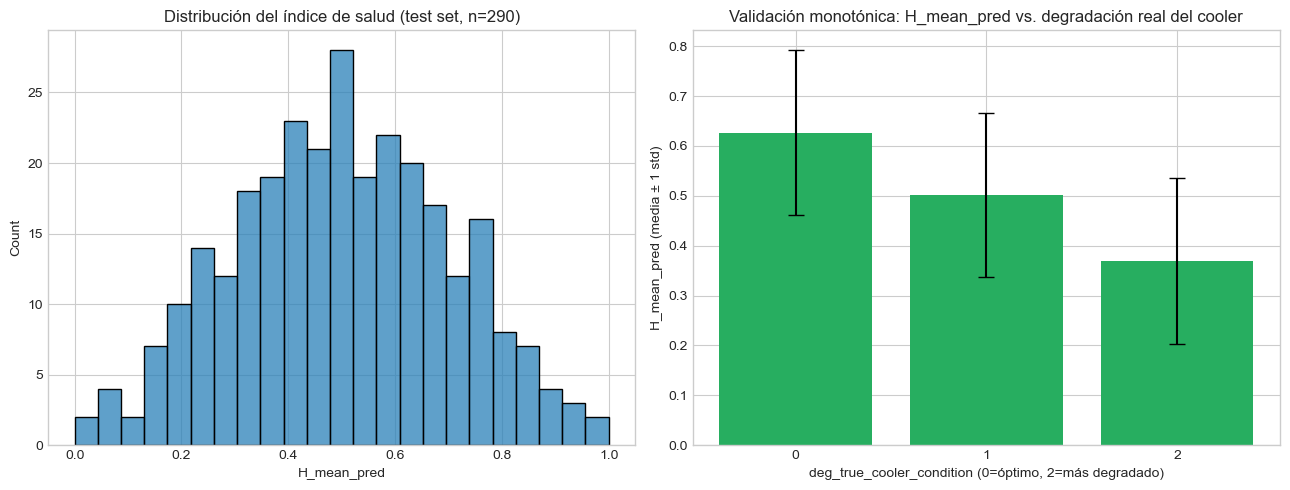

In [7]:
FIGURES_DIR = Path.cwd().parent / "reports" / "figures"  # misma carpeta que las Fases 1, 2, 3 y 4
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel A: distribución de H_mean_pred ──
sns.histplot(df["H_mean_pred"], bins=23, ax=axes[0], color="#2980b9")
axes[0].set_xlabel("H_mean_pred")
axes[0].set_title("Distribución del índice de salud (test set, n=290)")

# ── Panel B: H_mean_pred por nivel real de degradación del cooler, media ± std ──
axes[1].bar(
    cooler_validation.index.astype(str),
    cooler_validation["mean"],
    yerr=cooler_validation["std"],
    capsize=6,
    color="#27ae60",
)
axes[1].set_xlabel("deg_true_cooler_condition (0=óptimo, 2=más degradado)")
axes[1].set_ylabel("H_mean_pred (media ± 1 std)")
axes[1].set_title("Validación monotónica: H_mean_pred vs. degradación real del cooler")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_health_index_distribution.png", bbox_inches="tight")
plt.show()


### Interpretación

**El panel A confirma visualmente lo que la Sección 1 ya describía en números: una distribución sin concentración extrema, con estructura discreta visible pero cobertura razonable de todo el rango [0,1].** El histograma muestra picos separados en vez de una curva suave continua — el reflejo directo de que `H_mean_pred` solo puede tomar 23 valores posibles (Sección 1), no una limitación del gráfico. No hay ningún pico dominante que concentre una fracción desproporcionada de los 290 ciclos (a diferencia de `H_max_pred`, donde el 75.2% caía en un único valor) — consistente con la elección de `H_mean` como proxy principal, ya justificada en la Sección 1 por su mejor granularidad.

**El panel B hace visible la monotonía ya reportada, y también su límite: las barras de error se solapan parcialmente entre niveles adyacentes.** Las tres barras (0.6267, 0.5017, 0.3694) descienden con claridad y sin ambigüedad en la media — la validación monotónica se sostiene. Pero con std≈0.165 en los tres niveles y una diferencia entre medias de ~0.13 por escalón, las barras de ±1 std de niveles adyacentes se solapan visiblemente: un ciclo individual con `deg_true_cooler`=0 puede tener un `H_mean_pred` más bajo que otro con `deg_true_cooler`=1, simplemente por la variación que aportan los otros tres componentes. Esto es coherente con el diseño del índice, no una falla: `H_mean_pred` combina los 4 componentes por diseño, así que ningún componente por sí solo determina el valor exacto de un ciclo — la monotonía se cumple en la tendencia agregada (la media por nivel), no como una garantía determinista ciclo a ciclo. Es una distinción importante para cualquier uso operacional del proxy: sirve para comparar poblaciones o tendencias, no para inferir con certeza el estado del refrigerador de un ciclo individual a partir de su `H_mean_pred` en solitario.

**Ambas figuras cierran la Fase 5 documentando visualmente lo que las Secciones 1 y 2 ya habían cuantificado — quedan guardadas en `reports/figures/05_health_index_distribution.png`**, junto al resto de figuras del proyecto (EDA, heatmap de η² de la Fase 2, ROC/distribución de la Fase 3, matrices de confusión y scatter de la Fase 4).
